# Attribute Computation and Filtering

This notebook shows how to compute node attributes on valued morphological trees and use those attributes to build simple connected filters. It uses the same image to compare a max-tree, a min-tree, a Tree of Shapes hierarchy, and unrestricted and saturated self-dual residual trees.

In [1]:
import mmcfilters
import math
from pathlib import Path

import cv2 as cv
from IPython import display
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import mtviz as viz

plt.rcParams["figure.figsize"] = (16, 16)


def load_grayscale(path):
    image = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return np.ascontiguousarray(image, dtype=np.uint8)


## Load and inspect the input image

The examples use a grayscale test image. The image values define the altitude of the component tree nodes, while the grid adjacency controls which pixels may belong to the same connected component.


In [2]:
input_image = load_grayscale("../dat/imgTeste.png")
#input_image = load_grayscale("../dat/imgObjetos.png")
#input_image = load_grayscale("../dat/cable.png")
#input_image = load_grayscale("../dat/images/peppers_gray.tif")

(num_rows, num_columns) = input_image.shape



## Build a valued tree of shapes and compute attributes

`compute_attributes` evaluates several attribute calculators in one pass and returns a table indexed by node. The notebook keeps the attribute names in `attribute_indices` so later cells can select columns without hard-coded positions.


In [3]:
AT = mmcfilters.Attribute
tree = mmcfilters.MorphologicalTreeFactory.create_tree_of_shapes(input_image)
mmcfilters.Attribute.compute_attributes(tree, [AT.AREA, AT.VOLUME, AT.BOUNDING_BOX_HEIGHT])

({'AREA': 0, 'VOLUME': 1, 'BOUNDING_BOX_HEIGHT': 2},
 array([[2.5000000e+05, 3.2991864e+07, 5.0000000e+02],
        [3.3830000e+04, 3.7804140e+06, 2.0000000e+02],
        [1.1156400e+05, 1.0283698e+07, 4.7800000e+02],
        [8.9290000e+03, 6.4288800e+05, 1.1400000e+02],
        [1.5485000e+04, 8.3619000e+05, 1.8300000e+02],
        [2.4413000e+04, 2.4757900e+06, 2.8100000e+02],
        [1.6137000e+04, 2.2688160e+06, 1.7500000e+02],
        [3.0180000e+03, 1.5665700e+05, 6.8000000e+01],
        [4.2100000e+02, 1.6419000e+04, 2.3000000e+01],
        [6.8210000e+03, 2.5919800e+05, 9.7000000e+01]], dtype=float32))

In [4]:
import pandas as pd
ok = True
selected_attributes = [
    mmcfilters.Attribute.AREA,
    mmcfilters.Attribute.INERTIA,
    mmcfilters.Attribute.BOUNDING_BOX_HEIGHT,
]
trainset = ["../dat/imgTeste.png", "../dat/imgObjetos.png", "../dat/cable.png"]
for i in range(len(trainset)):
    img = load_grayscale(trainset[i])
    (img_rows, img_columns) = img.shape
    tree = mmcfilters.MorphologicalTreeFactory.create_tree_of_shapes(img)
    features, attribute_matrix = mmcfilters.Attribute.compute_topology_attributes(tree, selected_attributes)

    df2 = pd.DataFrame(attribute_matrix, columns=list(features.keys()))
    if len(df2[df2.isna().any(axis=1)]) > 0:
        print(i, df2[df2.isna().any(axis=1)])
        ok = False
if ok:
    print("Attributes verified, no NaN values found in the selected subset.")

Attributes verified, no NaN values found in the selected subset.


## Compare tree families

The same topology-based attribute set is computed on five hierarchy families. Self-dual residual trees publish an unconstrained altitude order, so the examples use direct and subtractive reconstruction rules, which do not require globally monotone altitudes. The saturated construction uses row-major pixel `0` as the infinity pixel. The Tree of Shapes uses the default topographic convention, which publishes unchanged 8-bit source levels over the canonical 4/8 complementary-grid immersion, so its reconstruction shares the `uint8` scale of the other four families.

In [5]:
tree_families = {
    "Max-tree": mmcfilters.MorphologicalTreeFactory.create_max_tree(
        input_image,
        radius=1.5,
    ),
    "Min-tree": mmcfilters.MorphologicalTreeFactory.create_min_tree(
        input_image,
        radius=1.5,
    ),
    "Tree of Shapes": mmcfilters.MorphologicalTreeFactory.create_tree_of_shapes(
        input_image,
    ),
    "Unrestricted residual": (
        mmcfilters.MorphologicalTreeFactory.create_unrestricted_residual_tree(
            input_image,
            radius=1.5,
        )
    ),
    "Saturated residual": (
        mmcfilters.MorphologicalTreeFactory.create_saturated_residual_tree(
            input_image,
            infinity_pixel=0,
            radius=1.5,
        )
    ),
}

selected_attributes = [
    mmcfilters.Attribute.AREA,
    mmcfilters.Attribute.INERTIA,
    mmcfilters.Attribute.BOUNDING_BOX_HEIGHT,
]

filters_by_family = {}
attribute_matrices = {}
attribute_indices = None
expected_reconstructions = {label: input_image for label in tree_families}

for label, hierarchy in tree_families.items():
    filters_by_family[label] = mmcfilters.AttributeFilters(hierarchy)
    current_indices, matrix = mmcfilters.Attribute.compute_topology_attributes(
        hierarchy,
        selected_attributes,
    )
    if attribute_indices is None:
        attribute_indices = current_indices
    else:
        assert current_indices == attribute_indices
    attribute_matrices[label] = matrix
    assert np.array_equal(
        hierarchy.reconstruct_from_node_altitudes(),
        expected_reconstructions[label],
    )
    print(f"{label}: {hierarchy.num_nodes} live nodes")

attribute_indices

Max-tree: 9 live nodes
Min-tree: 10 live nodes
Tree of Shapes: 10 live nodes
Unrestricted residual: 10 live nodes
Saturated residual: 10 live nodes


{'AREA': 0, 'BOUNDING_BOX_HEIGHT': 1, 'INERTIA': 2}

## Inspect one hierarchy

The tree printer summarizes the parent-child structure of the Tree of Shapes hierarchy. The family comparison above uses reconstruction checks and node counts because numeric node IDs are local to each construction.

In [6]:
tree_to_inspect = tree_families["Tree of Shapes"]
print_tree = viz.PrintTree(
    lambda node: tree_to_inspect.children(node),
    lambda node: f"id:{node}: altitude: {tree_to_inspect.node_altitude(node)}",
)
print_tree(tree_to_inspect.root)

                             id:0: altitude: 203
         ┌────────────────────────────┴┬────────────────────────────┐
id:1: altitude: 126            id:2: altitude: 78           id:4: altitude: 54
         |                   ┌─────────┴─────────┐                            
 id:3: altitude: 72 id:5: altitude: 126 id:6: altitude: 161                   
                             |                   |                            
                     id:9: altitude: 38  id:7: altitude: 54                   
                                                 |                            
                                         id:8: altitude: 39


## Filter by individual attributes

Area and inertia define different keep/reject decision rules. Applying each decision rule to all five hierarchies shows how the same attribute rule interacts with different tree topologies. The direct rule propagates the filtered parent level; the subtractive rule propagates accepted altitude residues.

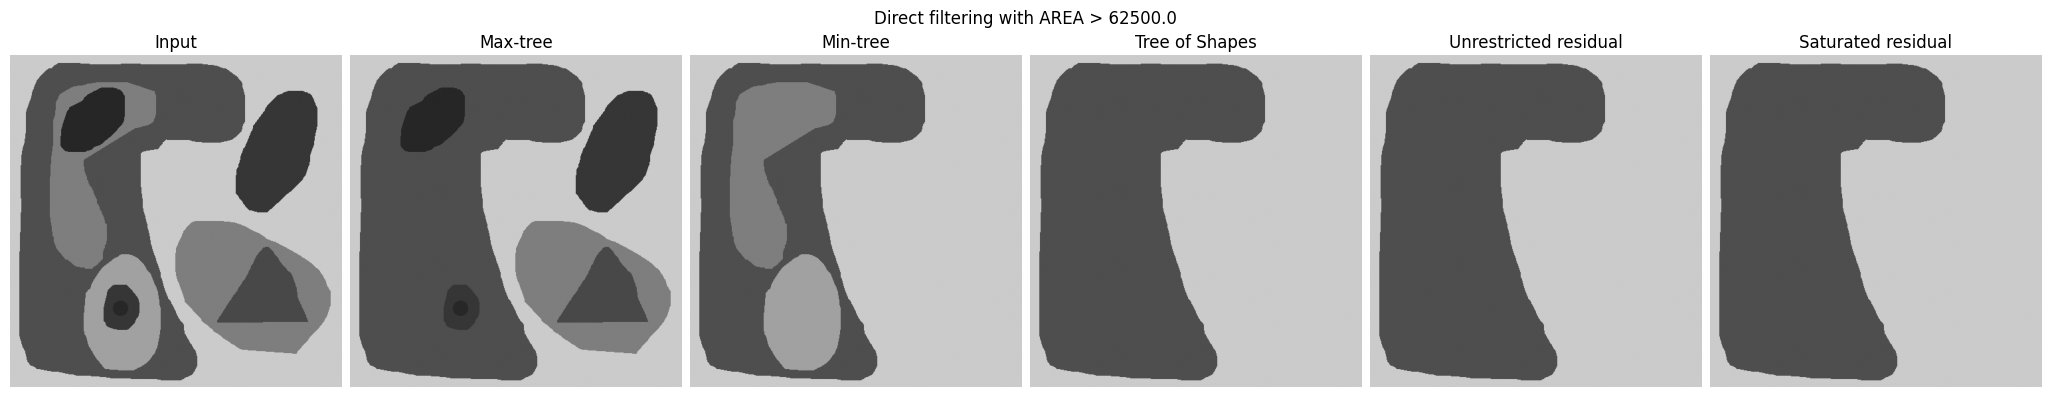

In [7]:
def show_family_results(filtered_images, heading):
    labels = ["Input", *filtered_images]
    images = [input_image, *filtered_images.values()]
    figure, axes = plt.subplots(
        1,
        len(images),
        figsize=(3.4 * len(images), 4),
        constrained_layout=True,
    )
    for axis, label, image in zip(axes, labels, images):
        display_image = (
            image.astype(np.float64) / 2
            if label == "Tree of Shapes"
            else image
        )
        axis.imshow(display_image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(label)
        axis.axis("off")
    figure.suptitle(heading)
    plt.show()


area_column = attribute_indices["AREA"]
area_threshold = (num_rows * num_columns) * 0.25
area_filtered_images = {}

for label in tree_families:
    area = np.ascontiguousarray(attribute_matrices[label][:, area_column])
    keep = (area > area_threshold).tolist()
    keep[tree_families[label].root] = True
    preservation_mask = mmcfilters.NodePreservationMask(keep)
    area_filtered_images[label] = mmcfilters.DirectAttributeFilter(tree_families[label]).apply_direct_attribute_filter(preservation_mask)

show_family_results(
    area_filtered_images,
    f"Direct filtering with AREA > {area_threshold:.1f}",
)

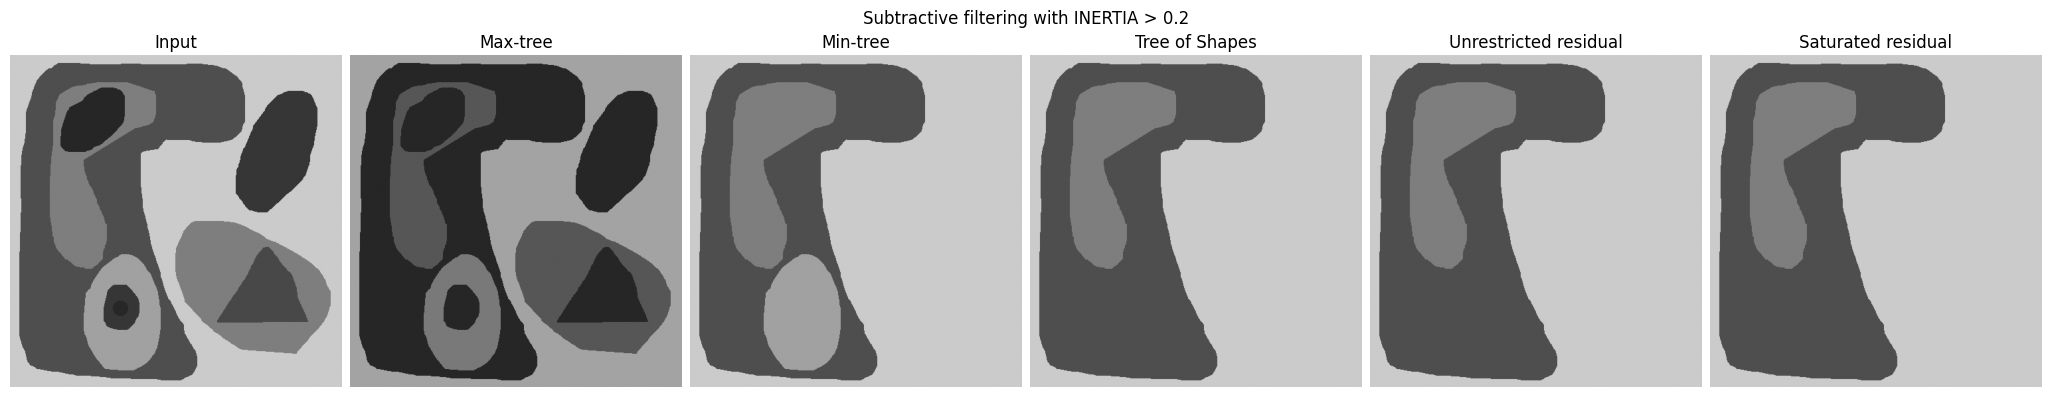

In [8]:
inertia_column = attribute_indices["INERTIA"]
inertia_threshold = 0.2
inertia_filtered_images = {}

for label in tree_families:
    inertia = np.ascontiguousarray(attribute_matrices[label][:, inertia_column])
    keep = mmcfilters.NodePreservationMask((inertia > inertia_threshold).tolist())
    inertia_filtered_images[label] = mmcfilters.HardSubtractiveAttributeFilter(tree_families[label]).apply_hard_subtractive_attribute_filter(keep)

show_family_results(
    inertia_filtered_images,
    f"Subtractive filtering with INERTIA > {inertia_threshold}",
)

## Checks

The final checks verify dense attribute layouts, exact reconstruction in each hierarchy's altitude units, and output dimensions for every hierarchy family.

In [9]:
for label, hierarchy in tree_families.items():
    assert attribute_matrices[label].shape == (
        hierarchy.num_internal_node_slots,
        len(attribute_indices),
    )
    assert np.array_equal(
        hierarchy.reconstruct_from_node_altitudes(),
        expected_reconstructions[label],
    )
    assert area_filtered_images[label].shape == input_image.shape
    assert inertia_filtered_images[label].shape == input_image.shape

print("All five hierarchy families passed the attribute and reconstruction checks.")

All five hierarchy families passed the attribute and reconstruction checks.
